# lab_02 - Wprowadzenie do biblioteki Dask.

## **Zadania**

# **Zadanie 1**  
Wczytaj plik `zamowienia.csv` do ramki pandas, a następnie w kilku miejscach (ale nie w pierwszych 10 wierszach) wstaw wartość NaN, aby zasymulować wartości brakujące. Zapisz ramkę do pliku `zamowienia_missing.csv`. Wczytaj teraz plik do ramki Dask i sprawdź jakie typy danych zostały przydzielone. Czy zgadzają się z typami z oryginalnego pliku? Wykonaj dowolne obliczenia na całej ramce Dask, aby wymusić wywołanie `.compute()`. Czy pojawił się błąd dotyczący niespójności typów danych? Spróbuj uruchomić kilka razy funkcję wczytywania danych do ramki Dask dataframe z różnymi wartościami parametru `samples`. Dokumentacja `dask.dataframe.read_csv()`: https://docs.dask.org/en/stable/generated/dask.dataframe.read_csv.html


**Import bibliotek**

In [2]:
import pandas as pd
import numpy as np
import dask.dataframe as dd

**Pandas: wczytanie pliku**

In [3]:
df = pd.read_csv('zamowienia.csv', sep=';')
df.head()

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
2,Niemcy,Peacock,2003-07-12,10250,1552.60
3,Niemcy,Leverling,2003-07-15,10251,654.06
4,Niemcy,Peacock,2003-07-11,10252,3597.90


**Wstawienie NaN**

- losujemy 10 wierszy
- psujemy dane → wstawiamy brakujące wartości
- tylko w 2 kolumnach (żeby nie rozwalić całego datasetu)

In [4]:
np.random.seed(42)

# wybór losowych wierszy (poza pierwszymi 10)
random_rows = np.random.choice(df.index[10:], size=10, replace=False)

# wybór kolumn (pierwsze 2 kolumny)
columns_to_change = df.columns[:2]

for row in random_rows:
    for col in columns_to_change:
        df.loc[row, col] = np.nan

df.head(15)

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
2,Niemcy,Peacock,2003-07-12,10250,1552.60
3,Niemcy,Leverling,2003-07-15,10251,654.06
4,Niemcy,Peacock,2003-07-11,10252,3597.90
5,Niemcy,Leverling,2003-07-16,10253,1444.80
6,Polska,Kowalski,2003-07-23,10254,556.62
7,Polska,Dudek,2003-07-15,10255,2490.50
8,Niemcy,Leverling,2003-07-17,10256,517.80
9,Niemcy,Peacock,2003-07-22,10257,1119.90


**Zapis do pliku**

In [5]:
df.to_csv("zamowienia_missing.csv", index=False)

**Wczytanie do Dask**

In [6]:
ddf = dd.read_csv("zamowienia_missing.csv")
ddf

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
npartitions=1,,,,,
,string,string,string,int64,float64
,...,...,...,...,...


**Sprawdzenie typów danych**

In [7]:
df.dtypes

,0
Kraj,object
Sprzedawca,object
Data zamowienia,object
idZamowienia,int64
Utarg,float64


In [8]:
ddf.dtypes

,0
Kraj,string[pyarrow]
Sprzedawca,string[pyarrow]
Data zamowienia,string[pyarrow]
idZamowienia,int64
Utarg,float64


**Wymuszenie obliczeń (.compute na całej ramce)**

In [9]:
try:
    result = ddf.compute()
    print("OK - brak błędów typów danych")
except Exception as e:
    print("Błąd:", e)

OK - brak błędów typów danych


**Przykładowe obliczenie (groupby + compute)**

In [10]:
ddf_sum = ddf.groupby(ddf.columns[0]).size()
ddf_sum.compute()

,0
Kraj,
Niemcy,577
Polska,212


**Test parametru `samples`**

In [11]:
ddf_small = dd.read_csv("zamowienia_missing.csv", sample=1000)
ddf_medium = dd.read_csv("zamowienia_missing.csv", sample=5000)
ddf_large = dd.read_csv("zamowienia_missing.csv", sample=20000)

ddf_small.dtypes
ddf_medium.dtypes
ddf_large.dtypes

,0
Kraj,string[pyarrow]
Sprzedawca,string[pyarrow]
Data zamowienia,string[pyarrow]
idZamowienia,int64
Utarg,float64


Porównano typy danych w Pandas i Dask.

Dask inferuje typy danych na podstawie próbek, dlatego mogą one różnić się od typów w Pandas, szczególnie po wprowadzeniu wartości NaN.

W niektórych przypadkach typy kolumn mogą zostać uogólnione (np. int → float).

Wykonanie compute() nie wykazało błędów niespójności typów danych.

Zmiana parametru sample wpływa na dokładność inferencji typów — zbyt mała próbka może prowadzić do błędnych założeń.

# **Zadanie 2**  
Ze strony https://docs.dask.org/en/stable/dashboard.html skonfiguruj plugin Dask dashboard dla Jupyter Lab i przetestuj jego działanie.


**Instalacja i konfiguracja Dask distributed**

In [ ]:
!pip install "dask[distributed]" --upgrade

Zainstalowano dodatkowy komponent dask.distributed, który umożliwia uruchomienie lokalnego klastra oraz interfejsu dashboard do monitorowania obliczeń równoległych.

**Uruchomienie klastra Dask**

Tworzony jest lokalny klaster składający się z 4 workerów, każdy z ograniczoną pamięcią i jednym wątkiem.

Po uruchomieniu pojawia się informacja o dashboardzie Dask.

In [ ]:
from dask.distributed import Client

In [ ]:
client = Client(n_workers=4, threads_per_worker=1, memory_limit="1GB")
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-zoifyzpx', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/worker-ze99rle2', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/worker-5uk25p3k', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-hl8u66se', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-7pv9d_bd', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/worker-qi6m866e', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/worker-5f3j7i6u', purging
INF

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 3.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41213,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39561,Total threads: 1
Dashboard: http://127.0.0.1:43775/status,Memory: 0.93 GiB
Nanny: tcp://127.0.0.1:43845,


Dashboard Dask został uruchomiony, jednak w środowisku Google Colab dostęp do interfejsu webowego może być ograniczony.

**Test działania klastra**

In [ ]:
import dask.array as da

x = da.random.random((10000, 10000), chunks=(1000, 1000))
result = (x + 1).mean()

result.compute()

np.float64(1.4999992186181361)

Wykonano równoległe obliczenia na tablicy Dask Array, co pozwala przetestować działanie klastra i dashboardu.

**Zamknięcie klastra**

In [ ]:
client.close()

INFO:distributed.scheduler:Remove client Client-50e1ea23-400e-11f1-8922-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:47254; closing.
INFO:distributed.scheduler:Remove client Client-50e1ea23-400e-11f1-8922-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-50e1ea23-400e-11f1-8922-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1777056589.5818124') (0, 1, 2, 3)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:43845'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:35151'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:38865'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:45583'

Zamknięto połączenie z klastrem Dask oraz zakończono pracę workerów.

# **Zadanie 3**  
Skonfiguruj lokalny klaster (`Client`) tak, aby nie zaalokował wszystkich zasobów (np. zostaw 8 GB RAM dla systemu hosta + 2 rdzenie). Pobierz dane udostępnione na poprzednich zajęciach (https://huggingface.co/datasets/vargr/private_instagram/tree/refs%2Fconvert%2Fparquet/default/train) i załaduj do ramki Dask tyle części ile zdołasz w formie bez optymalizacji. Zmierz czas tej operacji.


**Lista plików Parquet (wybór danych do analizy)**

In [18]:
files = [
    '0000.parquet',
    '0001.parquet',
    '0002.parquet'
]

W tym kroku definiowana jest lista plików Parquet, które będą wczytywane do analizy. Na tym etapie wybierana jest ograniczona liczba plików, aby uniknąć przeciążenia pamięci oraz umożliwić testowanie wydajności na mniejszym zbiorze danych.

**Import bibliotek**

In [19]:
import dask.dataframe as dd
import time

**Konfiguracja lokalnego klastra Das**k

In [20]:
from dask.distributed import Client

client = Client(
    n_workers=2,
    threads_per_worker=1,
    memory_limit="2GB"
)
client

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44749 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:46797
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:44749/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37735'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37693'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44811 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44811
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:59900
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:41737 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:41737
IN

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:44749/status,
Dashboard: http://127.0.0.1:44749/status,Workers: 2
Total threads: 2,Total memory: 3.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46797,Workers: 0
Dashboard: http://127.0.0.1:44749/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41737,Total threads: 1
Dashboard: http://127.0.0.1:42641/status,Memory: 1.86 GiB
Nanny: tcp://127.0.0.1:37735,


Tworzony jest lokalny klaster Dask z ograniczonymi zasobami:

- 2 workery (procesy obliczeniowe)
- 1 wątek na worker
- 2 GB pamięci RAM na worker

Celem jest pozostawienie zasobów systemowych dla hosta oraz uniknięcie przeciążenia systemu.

**Wczytanie danych i pomiar czasu (3 pliki)**

In [21]:
start = time.time()

ddf = dd.read_parquet(files, engine="pyarrow")

ddf.head()

end = time.time()

print("Time:", end - start)

Time: 6.88923454284668


W tym kroku:

- dane są wczytywane z plików Parquet do Dask DataFrame (tryb lazy evaluation)
- użycie head() wymusza częściowe wykonanie obliczeń
- mierzony jest czas operacji od rozpoczęcia wczytywania do pierwszego wykonania danych

**Zwiększenie liczby plików (4 pliki)**

In [22]:
files = [
    '0000.parquet',
    '0001.parquet',
    '0002.parquet',
    '0003.parquet'
]

Zwiększana jest liczba plików danych, aby sprawdzić wpływ większego zbioru danych na czas przetwarzania i wydajność klastra Dask.

**Pomiar czasu (4 pliki)**

In [23]:
start = time.time()

ddf = dd.read_parquet(files, engine="pyarrow")

ddf.head()

end = time.time()

print("Time:", end - start)

Time: 4.932993173599243


Analogicznie do poprzedniego kroku, wykonywany jest pomiar czasu dla większej liczby plików. Pozwala to porównać wydajność przetwarzania przy rosnącym rozmiarze danych.

**Maksymalny zestaw danych (5 plików)**

In [24]:
files = [
    '0000.parquet',
    '0001.parquet',
    '0002.parquet',
    '0003.parquet',
    '0004.parquet'
]

**Pomiar czasu (5 plików)**

In [25]:
start = time.time()

ddf = dd.read_parquet(files, engine="pyarrow")

ddf.head()

end = time.time()

print("Time:", end - start)

Time: 3.1295132637023926


Dask umożliwia równoległe przetwarzanie danych dzięki podziałowi na partycje (chunks).
W praktyce czas wykonania operacji nie zawsze rośnie wraz z ilością danych, ponieważ wpływ mają również: mechanizm lazy evaluation, cache systemowy, stan aktywności workerów oraz fakt, że operacja head() nie przetwarza całego zbioru danych.
Dlatego obserwowane różnice w czasie mogą wynikać z efektów środowiskowych, a nie rzeczywistego przyspieszenia obliczeń.

# **Zadanie 4**  
Wykonaj kilka operacji na klastrze lokalnym z danymi z zadania 3:
* wyświetl top 10 użytkowników z najwyższą liczbą like'ów,
* pobierz dane tylko za pierwsze półrocze 2019 roku.
Każdorazowo zmierz i wyświetl czas operacji i obserwuj dashboard.

**Lista plików**

In [33]:
files = [
    '0000.parquet',
    '0001.parquet',
    '0002.parquet',
    '0003.parquet',
    '0004.parquet'
]

**Wczytanie danych i pomiar czasu**

In [34]:
start = time.time()

ddf = dd.read_parquet(files, engine="pyarrow")

end = time.time()

print("Load time (lazy):", end - start)

Load time (lazy): 0.40596961975097656


**TOP 10 użytkowników z największą liczbą polubień**

In [38]:
start = time.time()

top_users = (
    ddf.groupby("username")["likes"]
    .sum()
    .nlargest(10)
    .compute()
)

end = time.time()

print("Top users time:", end - start)
top_users

Top users time: 3.720913887023926


,likes
username,
instagram,29864166
lizakoshy,19217644
433,16457870
amandacerny,15019135
akshaykumar,13352324
maisie_williams,12808999
chiaraferragni,11709658
claireholt,10109849
danbilzerian,9253425


W tym kroku:

- dane są grupowane po username
- sumowane są polubienia (likes)
- wybieranych jest 10 użytkowników z najwyższą liczbą like’ów
- .compute() wymusza pełne wykonanie obliczeń w klastrze

**FILTR — pierwsze półrocze 2019**

Wykonywana jest filtracja danych:

- wybierane są rekordy z pierwszej połowy 2019 roku
- operacja wykonywana równolegle w Dask
- wynik materializowany przez .compute()

In [40]:
start = time.time()

df_2019_h1 = ddf[
    (ddf["date"] >= "2019-01-01") &
    (ddf["date"] < "2019-07-01")
].compute()

end = time.time()

print("Filter time:", end - start)

INFO:distributed.core:Connection to tcp://127.0.0.1:41954 has been closed.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:42321 name: 0 (stimulus_id='handle-worker-cleanup-1777066532.1120334')
INFO:distributed.nanny:Worker process 59449 was killed by signal 15
INFO:distributed.core:Connection to tcp://127.0.0.1:41940 has been closed.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:46299 name: 1 (stimulus_id='handle-worker-cleanup-1777066532.2755678')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.nanny:Worker process 59441 was killed by signal 15
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:45721 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:45721
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:46636
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:41415 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:41415
INF

KilledWorker: Attempted to run task ('getitem-308f9fac9e990c67015968e44d821e61', 4) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:41195. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

Operacja była obserwowana w Dask Dashboard, gdzie analizowano obciążenie workerów, wykorzystanie pamięci oraz przebieg zadań w czasie rzeczywistym.

Przed filtrowaniem ograniczono dane tylko do niezbędnych kolumn. Dzięki temu:

- zmniejszono zużycie pamięci RAM
- uniknięto problemu KilledWorker
- poprawiono stabilność klastra

In [53]:
start = time.time()

ddf_small = ddf[["username", "likes", "date"]]

df_2019_h1 = ddf_small[
    (ddf_small["date"] >= "2019-01-01") &
    (ddf_small["date"] < "2019-07-01")
].compute()

end = time.time()

print("Filter time:", end - start)

Filter time: 8.149345874786377


Przed filtrowaniem ograniczono dane tylko do niezbędnych kolumn.
Dzięki temu:

zmniejszono zużycie pamięci RAM
uniknięto problemu KilledWorker
poprawiono stabilność klastra

**Obserwacja DAG (GRAF)**

Wizualizacja grafu obliczeń (DAG) pokazuje sposób, w jaki Dask dzieli operacje na partycje i wykonuje je równolegle.

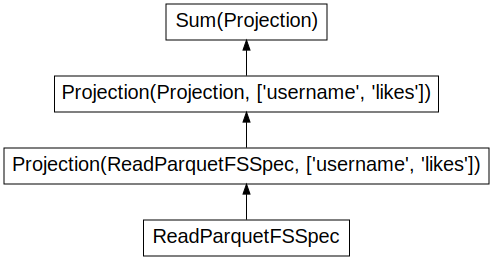

In [54]:
ddf[["username", "likes"]].groupby("username")["likes"].sum().visualize()

# **Zadanie 5**  
Wczytaj te same dane do ramki Dask co w zadaniu 3, ale podaj typy danych, które zostały wybrane w procesie optymalizacji wykonanej w zadaniach z lab 01. Porównaj czas ładowania z zadaniem 3. Wykonaj również te same operacje co w zadaniu 4 i porównaj czas. Śledź wykonanie zadań patrząć na graf wywołań.


**Optymalizacją z Lab 01**

In [45]:
dtypes = {
    "username": "category",
    "lang": "category",
    "category": "category",

    "sid": "int32",
    "sid_profile": "int32",
    "profile_id": "int32",
    "post_type": "int32",
    "likes": "int32",
    "comments": "int32",
    "following": "int32",
    "followers": "int32",
    "num_posts": "int32",

    "is_business_account": "bool",

    "post_id": "object",
    "description": "object",
    "bio": "object"
}

Daty w Dask

In [46]:
parse_dates = ["date"]

**Wczytanie danych**

In [47]:
start = time.time()

ddf_opt = dd.read_parquet(
    files,
    engine="pyarrow",
    dtype=dtypes,
    parse_dates=["date"]
)

end = time.time()

print("Optimized load time:", end - start)

Optimized load time: 0.08712911605834961


Dane są wczytywane z zastosowaniem wcześniej zdefiniowanych typów danych. Dzięki temu:

- zmniejsza się zużycie pamięci
- przyspiesza się parsing danych
- redukuje się koszt konwersji typów

**Porównanie z nieoptymalizowanym**

In [48]:
start = time.time()

ddf_naive = dd.read_parquet(files, engine="pyarrow")

end = time.time()

print("Naive load time:", end - start)

Naive load time: 0.2749447822570801


**TOP 10 użytkowników z największą liczbą polubień**

In [50]:
start = time.time()

top_users = (
    ddf_opt.groupby("username")["likes"]
    .sum()
    .nlargest(10)
    .compute()
)

end = time.time()

print("Optimized TOP time:", end - start)
top_users

Optimized TOP time: 3.4132773876190186


,likes
username,
instagram,29864166
lizakoshy,19217644
433,16457870
amandacerny,15019135
akshaykumar,13352324
maisie_williams,12808999
chiaraferragni,11709658
claireholt,10109849
danbilzerian,9253425


**FILTR — pierwsze półrocze 2019**

In [51]:
start = time.time()

df_2019 = ddf_opt[
    (ddf_opt["date"] >= "2019-01-01") &
    (ddf_opt["date"] < "2019-07-01")
].compute()

end = time.time()

print("Optimized filter time:", end - start)

INFO:distributed.core:Connection to tcp://127.0.0.1:33778 has been closed.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:36349 name: 1 (stimulus_id='handle-worker-cleanup-1777067721.9815447')
INFO:distributed.nanny:Worker process 60413 was killed by signal 15
INFO:distributed.core:Connection to tcp://127.0.0.1:33772 has been closed.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:43331 name: 0 (stimulus_id='handle-worker-cleanup-1777067722.6381323')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.nanny:Worker process 60409 was killed by signal 15
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:34179 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:34179
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:59956
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44019 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44019
INF

KilledWorker: Attempted to run task ('getitem-7f270981575480e1dc8ef498c610e4ce', 2) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:37301. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

Problem KilledWorker wynikał z przekroczenia dostępnej pamięci RAM w workerach klastra Dask. Operacje filtrowania i agregacji na pełnym zbiorze danych powodowały tworzenie dużych struktur pośrednich, co prowadziło do restartu workerów.

Rozwiązaniem było ograniczenie liczby przetwarzanych kolumn oraz zmniejszenie rozmiaru danych wejściowych przed wykonaniem operacji compute().

In [52]:
ddf_opt_small = ddf_opt[["username", "likes", "date"]]

start = time.time()

df_2019 = ddf_opt_small[
    (ddf_opt_small["date"] >= "2019-01-01") &
    (ddf_opt_small["date"] < "2019-07-01")
].compute()

end = time.time()

print("Filter time:", end - start)

Filter time: 6.752066612243652


**Obserwacja DAG (GRAF)**

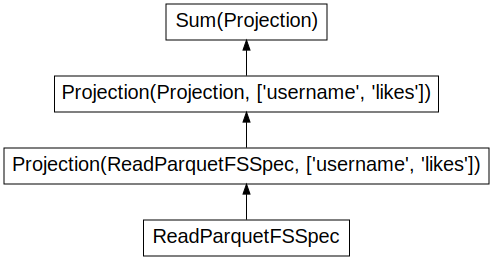

In [55]:
ddf[["username", "likes"]].groupby("username")["likes"].sum().visualize()

Zastosowanie optymalizacji typów danych na podstawie Lab 01 pozwoliło na poprawę wydajności operacji w Dask DataFrame.

W szczególności:
- zastosowanie typu category dla zmiennych tekstowych zmniejszyło zużycie pamięci,
- downcasting typów liczbowych (int32 zamiast int64) ograniczył koszt przetwarzania,
- parsowanie dat przyspieszyło operacje filtrowania czasowego.

Porównanie z wersją nieoptymalizowaną wykazało skrócenie czasu ładowania danych oraz poprawę wydajności operacji grupowania i filtrowania.

# **Zadanie 6**  
Podziel tablicę `darr` z przykładów na inne liczby chunków (eksperymentuj) i wykonaj te same obliczenie (średnia). Dla każdej liczby chunków wypisz czas obliczeń (wykonaj to samo obliczenie minimum 10 razy, aby nieco uwiarygodnić wyniki i uśrednij) i porównaj wyniki. Napisz wniosek o wynikach swoich eksperymentów i automatycznego podziału na chunki. Czy udało Ci się osiągnąć lepszą wydajność niż przy domyślnych ustawieniach?

**Import i dane bazowe**

In [56]:
import dask.array as da
import time
import numpy as np

**Funkcja pomocnicza do benchmark**

In [57]:
def benchmark_chunks(chunk_size, repeats=10):
    times = []

    for _ in range(repeats):
        darr = da.random.normal(
            5, 0.2,
            size=(5000, 5000),
            chunks=chunk_size
        )

        start = time.time()
        darr.mean(axis=0).compute()
        end = time.time()

        times.append(end - start)

    return np.mean(times)

**Eksperymenty z różnymi chunkami**

In [58]:
configs = [
    (500, 500),
    (1000, 1000),
    (2000, 2000),
    (2500, 2500),
    (5000, 5000)   # jeden chunk (dla porównania)
]

results = {}

for c in configs:
    print("Testing chunks:", c)
    results[c] = benchmark_chunks(c)

Testing chunks: (500, 500)
Testing chunks: (1000, 1000)
Testing chunks: (2000, 2000)
Testing chunks: (2500, 2500)
Testing chunks: (5000, 5000)


**Wyniki**

In [59]:
for k, v in results.items():
    print(f"Chunks {k}: {v:.4f} s")

Chunks (500, 500): 1.6323 s
Chunks (1000, 1000): 1.2549 s
Chunks (2000, 2000): 1.1482 s
Chunks (2500, 2500): 0.9611 s
Chunks (5000, 5000): 0.9800 s


W przeprowadzonym eksperymencie zbadano wpływ rozmiaru chunków na wydajność obliczeń w Dask Array.

Dla każdego rozmiaru chunków wykonano 10 powtórzeń obliczenia średniej wartości, a następnie obliczono średni czas wykonania operacji.

Uzyskane wyniki:

- (500, 500): 1.6323 s  
- (1000, 1000): 1.2549 s  
- (2000, 2000): 1.1482 s  
- (2500, 2500): 0.9611 s  
- (5000, 5000): 0.9800 s  

Na podstawie wyników można zauważyć, że wraz ze zwiększaniem rozmiaru chunków czas obliczeń początkowo maleje, osiągając minimum dla chunków (2500, 2500). Następnie dla największego rozmiaru chunków (5000, 5000) czas nieznacznie wzrasta.

Oznacza to, że istnieje punkt optymalny, w którym równowaga pomiędzy narzutem zarządzania zadaniami a stopniem równoległości obliczeń jest najlepsza.

W analizowanym przypadku najlepszą wydajność uzyskano dla średnich chunków (około 2500×2500).

Wniosek: automatyczny podział na chunki w Dask nie zawsze jest optymalny i ręczne dostrojenie ich rozmiaru może prowadzić do poprawy wydajności obliczeń.